In [1]:
import random
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cup_gather_data import hcgcr_data
from cup_main_gather_queue_data import updateCR
from cup_functions import update_queue_add_all_neighbors, \
    update_queue_remove_asymmetric, update_queue_remove_unchanged_orbits
from hcgcr import hcgcr

sns.set_theme(style="whitegrid")
update_functions = [update_queue_add_all_neighbors, update_queue_remove_asymmetric, update_queue_remove_unchanged_orbits]



In [6]:
# python checks
log_pi_table = np.load("log_pi_table.npy")
a = np.array([1,1,5,1])
print(log_pi_table[0:10])
print(log_pi_table[a])

[     -inf 0.6931472 1.0986123 1.6094379 1.9459101 2.3978953 2.5649494
 2.8332133 2.944439  3.1354942]
[0.6931472 0.6931472 2.3978953 0.6931472]


queue_update_function is one of the following: [update_queue_add_all_neighbors, update_queue_remove_asymmetric, update_queue_remove_unchanged_orbits]

In [2]:
def is_coloring_correct(G, c_test):
    c, _ = pd.factorize(c_test)
    c_test_recolored = pd.Series(c+1)
    c_correct = hcgcr(G)
    return c_test_recolored.equals(c_correct)

def add_random_edge(G):
    non_edges = list(nx.non_edges(G))
    if not non_edges:  # Check if there are no available edges
        print("No non-edges available to add.")
        return False, False
    G_new = G.copy()
    new_edge = random.choice(non_edges)
    G_new.add_edge(new_edge[0], new_edge[1])
    return G_new, new_edge

# testing based on binomial random graphs
def random_testing_correctness(test_size, test_min_n, test_max_n, p):
    i = 0
    correct_nr = 0
    incorrect_list = [[], [], []]
    print(incorrect_list)
    while i < test_size:
        print("Iteration ", i)
        n1 = random.randint(test_min_n, test_max_n)
        G1 = nx.fast_gnp_random_graph(n1,p)
        
        G2, new_edge = add_random_edge(G1)
        iterations = hcgcr_data(G1)
        j = 0
        correct = True
        for queue_update_function in update_functions:
            iterations_up_list, _ = updateCR(G2, new_edge, iterations, queue_update_function)
            c_updated = iterations_up_list[-1].coloring['color'] 
            is_correct = is_coloring_correct(G2, c_updated)
            if is_correct != True:
                correct = False
                incorrect_list[j].append([G1, new_edge])
            j += 1
        if correct == True:
            correct_nr += 1
        i += 1
    results = [correct_nr, incorrect_list]
    return results

In [ ]:
test_size, test_min_n, test_max_n, p = 20, 10, 100, 0.5
results = random_testing_correctness(test_size, test_min_n, test_max_n, p)
results


[[], [], []]
Iteration  0


KeyboardInterrupt: 

**Compare the number of recolored vertices**

In [ ]:
# trees

def number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p):
    i = 0
    n_list = []
    q_lists = [[],[],[]]
    number_of_iterations = []
    
    while i < test_size:
        n = random.randint(test_min_n, test_max_n)
        G1 = nx.random_unlabeled_tree(n, seed=None)
        G2, new_edge = add_random_edge(G1)
        
        iterations = hcgcr_data(G1)
        
        #dynamical
        j = 0
        for queue_update_function in update_functions:
            _, queues_lists = updateCR(G2, new_edge, iterations, queue_update_function)
            q_lists[j].append([len(q) for q in queues_lists])
            j += 1
        # static
        
        iterations = hcgcr_data(G2)
        number_of_iterations.append(len(iterations))
        n_list.append(n)
        
        i+=1

    return n_list, q_lists, number_of_iterations

In [ ]:
test_size, test_min_n, test_max_n, p = 10, 10, 30, 0.4
n_list, q_lists, number_of_iterations = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p)

[{12, 6}, {9, 12, 4, 6}, {3, 4, 5, 6, 7, 8, 9, 10, 12, 13}, {2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}]
[{12, 6}, {9, 12, 4, 6}, {9, 12, 4, 6}, {9, 12, 4, 6}, {9, 12, 4, 6}]
[{12, 6}, {9, 12, 4, 6}, {3, 4, 5, 6, 7, 9, 12}, {4, 5, 6, 7, 9, 12}, {4, 5, 6, 7, 9, 12}]
[{0, 9}, {0, 1, 4, 7, 9, 12}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}]
[{0, 9}, {0, 1, 4, 7, 9, 12}, {0, 9, 4, 7}, {0, 9, 7}, {0, 9, 7}]
[{0, 9}, {0, 1, 4, 7, 9, 12}, {0, 9, 4, 7}, {0, 9, 7}, {0, 9, 7}]
[{1, 15}, {0, 1, 14, 15}, {0, 1, 9, 14, 15, 16}, {0, 1, 16, 2, 9, 10, 14, 15}, {0, 1, 2, 3, 9, 10, 11, 12, 13, 14, 15, 16}, {0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15, 16}]
[{1, 15}, {0, 1, 14, 15}, {0, 1, 9, 14, 15, 16}, {0, 1, 14, 15}, set()]
[{1, 15}, {0, 1, 14, 15}, set()]
[{18, 7}, {0, 6, 7, 8, 10, 11, 12, 18}, {0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 18}, {0, 1, 2, 3, 6, 7, 8

In [ ]:
print(number_of_iterations)
print(q_lists[0])
print(q_lists[1])
print(q_lists[2])

[4, 4, 5, 4, 4, 4, 5, 5, 5, 4]
[[2, 4, 10, 13, 15], [2, 6, 13, 13, 13], [2, 4, 6, 8, 12, 14], [2, 8, 13, 15, 19], [2, 4, 6, 8, 10], [2, 11, 14, 17, 1], [2, 7, 19, 23, 25, 1], [2, 5, 9, 12, 12, 1], [2, 5, 13, 19, 22, 23], [2, 5, 7, 10, 1]]
[[2, 4, 4, 4, 4], [2, 6, 4, 3, 3], [2, 4, 6, 4, 0], [2, 5, 2, 0], [2, 4, 5, 4, 3], [2, 6, 8, 8, 1], [2, 7, 8, 5, 3, 1], [2, 5, 8, 3, 3, 1], [2, 5, 4, 3, 0], [2, 5, 5, 5, 1]]
[[2, 4, 7, 6, 6], [2, 6, 4, 3, 3], [2, 4, 0], [2, 5, 2, 0], [2, 4, 5, 4, 3], [2, 6, 8, 8, 1], [2, 7, 8, 5, 3, 1], [2, 5, 8, 3, 0], [2, 5, 4, 3, 0], [2, 5, 5, 5, 1]]


In [ ]:

print(q_lists[0])
print(q_lists[1])
print(q_lists[2])

[[2, 6, 10, 17, 24, 25], [2, 6, 12, 13, 16, 18], [2, 5, 8, 15, 19, 23, 26, 28], [2, 4, 8, 12, 14, 16], [2, 7, 13, 16, 21], [2, 4, 7, 11, 14], [2, 6, 13, 17, 20], [2, 6, 12, 19, 26, 29], [2, 3, 6, 7, 11, 15], [2, 4, 9, 16, 22, 25]]
[[2, 6, 8, 7, 4, 4], [2, 6, 9, 8, 7, 4], [2, 5, 6, 4, 4, 4, 4, 4], [2, 4, 4, 4, 4, 4], [2, 7, 9, 6, 0], [2, 4, 3, 0], [2, 6, 8, 8, 7], [2, 6, 8, 0], [2, 3, 3, 3, 3, 3], [2, 4, 9, 15, 13, 10]]
[[2, 6, 8, 7, 4, 4], [2, 6, 9, 8, 7, 4], [2, 5, 6, 4, 4, 4, 4, 4], [2, 4, 4, 4, 4, 4], [2, 7, 9, 6, 0], [2, 4, 3, 0], [2, 6, 8, 8, 7], [2, 6, 0], [2, 3, 3, 3, 3, 3], [2, 4, 9, 15, 13, 10]]


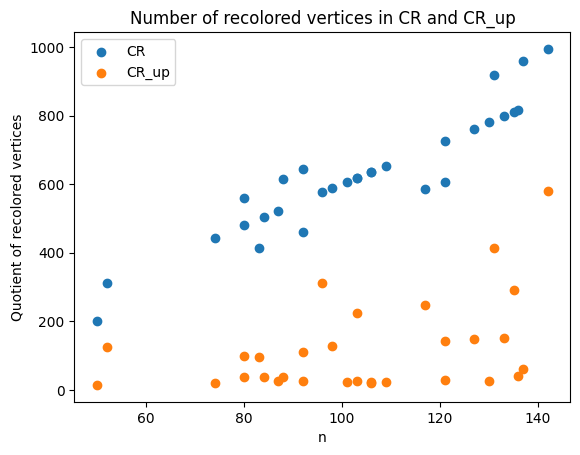

In [ ]:
test_size, test_min_n, test_max_n, p = 30, 50, 150, 0.7
n_list, q_sums_lists, n_k_sums_lists = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p)

ns = sorted(n_list)
qcr = [t for _, t in sorted(zip(n_list, n_k_sums_lists))]
qup = [t for _, t in sorted(zip(n_list, q_sums_lists))]
plt.scatter(ns,qcr, label = 'CR')
plt.scatter(ns,qup, label = 'CR_up')
#plt.ylim(0, 5)
plt.legend()
plt.xlabel('n')
plt.ylabel('Quotient of recolored vertices')
plt.title('Number of recolored vertices in CR and CR_up')

x = np.linspace(test_min_n, test_max_n, 5)
#plt.plot(x, 1/200*x*np.log(x))
#plt.plot(x, 1/6000*x**2)
plt.show()

HOW MANY VERTICES CHANGED COLOR AT THE END

In [148]:
def pair_generator(n): 
    used_pairs = set() 
    while True: 
        pair = random.sample(range(n), 2)
        pair = tuple(sorted(pair))
        if pair not in used_pairs: 
            used_pairs.add(pair) 
            yield pair 

def change_random_set_of_edges(G, s_len):
    G_new = G.copy()
    S = set()
    for _ in range(s_len):
        edge = next(pair_generator(len(G_new.nodes)))
        if G_new.has_edge(edge[0], edge[1]):
            G_new.remove_edge(edge[0], edge[1])
        else:
            G_new.add_edge(edge[0], edge[1])
        S.add(edge[0])
        S.add(edge[1])
    return G_new, S


def number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p, s_p, graph_type):
    i = 0
    n_list = []
    differences = [[], [], []]
    q_lists = [[],[],[]]
    longer = []
    
    while i < test_size:
        n = random.randint(test_min_n, test_max_n)
        if graph_type == 'tree':
            G1 = nx.random_labeled_tree(n, seed=None)
        else:
            G1 = nx.fast_gnp_random_graph(n, p)
        G2, S = change_random_set_of_edges(G1, int(np.floor(s_p*n*n/2)))
        
        iterations = hcgcr_data(G1)
        c = iterations[-1].coloring.color
        
        j = 0
        for queue_update_function in update_functions:
            iterations_up, q_list = updateCR(G2, S, iterations, queue_update_function)
            q_lists[j].append([len(q) for q in q_list])
            c_up = iterations_up[-1].coloring.color
            diff = len(c.compare(c_up))
            differences[j].append(diff)
            j += 1
        
        n_list.append(n)
        i+=1

    return n_list, differences, q_lists

In [ ]:
test_size = 10
test_min_n = 20
test_max_n = 50
p = 0.3
s_p = 0.1
graph_type = 'tree'

n_list, differences, q_lists = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p, s_p, graph_type)

125
28
101
54
42
115
24
39
76
48


In [ ]:
print(n_list)
for i in range(3):
    print(differences[i])
    print("xxx")

[50, 24, 45, 33, 29, 48, 22, 28, 39, 31]
[False, False, False, False, False, False, False, False, False, False]
[50, 24, 45, 33, 29, 48, 22, 28, 39, 31]
xxx
[28, 8, 35, 13, 15, 40, 8, 10, 39, 4]
xxx
[28, 8, 35, 13, 15, 40, 8, 10, 39, 4]
xxx


In [153]:
test_size = 50
test_min_n = 50
test_max_n = 200
p = 0.3
s_p = 0.1
graph_type = "tree"

n_list, differences, q_lists = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p, s_p, graph_type)


In [152]:
print(differences)

[[59, 69, 155, 136, 66, 146, 156, 170, 171, 156, 51, 171, 67, 119, 98, 53, 88, 93, 112, 183, 57, 95, 189, 191, 127, 68, 132, 77, 68, 77, 188, 117, 164, 63, 189, 191, 51, 100, 65, 132, 128, 86, 149, 100, 133, 76, 67, 165, 194, 178], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


<Axes: xlabel='n', ylabel='recolored vertices'>

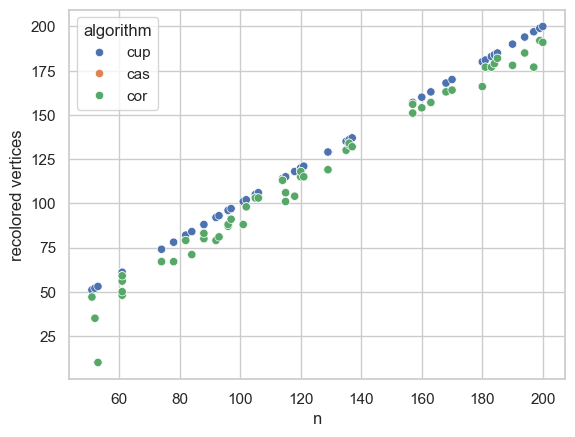

In [155]:
ns = sorted(n_list)
dcup = [d for _, d in sorted(zip(n_list, differences[0]))]
dcas = [d for _, d in sorted(zip(n_list, differences[1]))]
dcor = [d for _, d in sorted(zip(n_list, differences[2]))]

df = pd.DataFrame({
    "n": ns,
    "cup": dcup,
    "cas": dcas,
    "cor": dcor
})
df_long = df.melt(id_vars='n', var_name='algorithm', value_name='recolored vertices')
sns.scatterplot(data=df_long, x="n", y="recolored vertices", hue="algorithm")


In [156]:
test_size = 50
test_min_n = 50
test_max_n = 200
p = 0.3
s_p = 0.05
graph_type = "tree"

n_list_1, differences_1, _ = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p, s_p, graph_type)


KeyboardInterrupt: 

In [ ]:
test_size = 50
test_min_n = 50
test_max_n = 200
p = 0.3
s_p = 0.01
graph_type = "tree"

n_list_2, differences_2, _ = number_of_recolored_vertices_testing(test_size, test_min_n, test_max_n, p, s_p, graph_type)

In [125]:
G1 = nx.random_labeled_tree(15, seed=None)
G2, S = change_random_set_of_edges(G1, 1)

iterations = hcgcr_data(G1)
c = iterations[-1].coloring.color
c_list = []
n_list = []
differences = [[], [], []]
q_lists = [[],[],[]]
longer = []
j = 0
for queue_update_function in update_functions:
    iterations_up, q_list = updateCR(G2, S, iterations, queue_update_function)
    q_lists[j].append([len(q) for q in q_list])
    c_up = iterations_up[-1].coloring.color
    c_list.append(c_up)
    diff = len(c.compare(c_up))
    differences[j].append(diff)
    if j == 0:
        longer.append(len(iterations) < len(iterations_up))
    j += 1

In [129]:
print(longer)
print(differences)
print(q_lists)

[False]
[[12], [2], [2]]
[[[2, 5, 8, 10, 12, 14]], [[2, 5, 7, 6, 4, 4]], [[2, 5, 7, 6, 4, 4]]]


C:\Users\korol\AppData\Local\Temp\ipykernel_13304\2326781640.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)  # up to 20 distinct colors


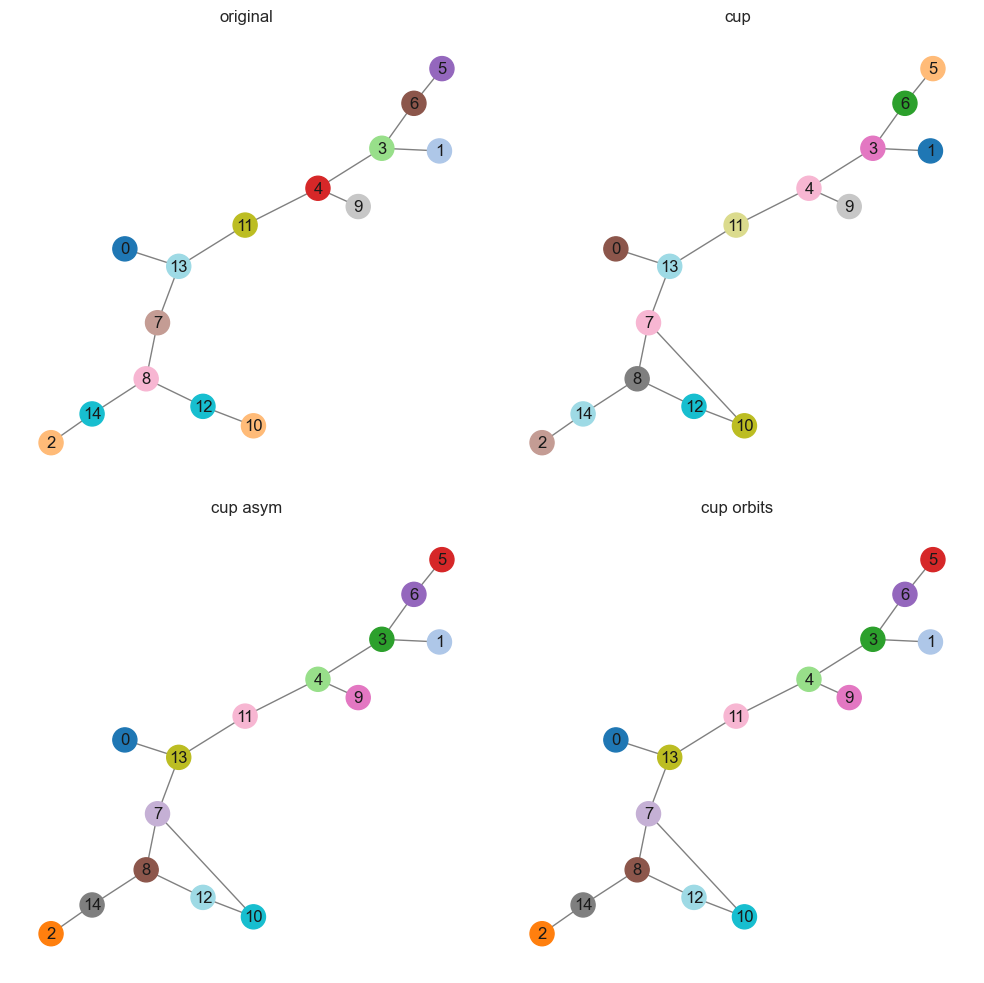

In [ ]:
# WYGENEROWAĆ PRZYKŁAD

pos = nx.spring_layout(G1, seed=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

color_sets = [c, *c_list]
titles = ['original', 'cup', 'cup asym', 'cup orbits']

# use a bright qualitative colormap (more distinct than tab10)
cmap = plt.cm.get_cmap('tab20', 20)  # up to 20 distinct colors
i = 0
for ax, cs, title in zip(axes, color_sets, titles):
    if i == 0: 
        G = G1 
    else: 
        G = G2
    i+= 1
    color_map = [cs.loc[node] for node in G.nodes()]
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=color_map,
        cmap=cmap,
        edge_color='gray',
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()
